# Business Understanding - ECG
ECG (Electrocardiogram) signals are electrical recordings of the heart's activity. They reflect the heart's function by showing the timing and strength of electrical impulses as they travel through the heart. <br>

An ECG (Electrocardiogram) is a test that records the electrical activity of your heart. It shows how the heart is beating and the strength of each beat.

Think of it like a graph that displays the heart's electrical signals, helping doctors see how well your heart is working.

<br>ECG signals are used to detect and monitor various heart conditions, such as arrhythmias, heart attacks, and other cardiac disorders.

The heart's electrical signals are impulses that coordinate the heartbeat by triggering contractions in the heart muscles.

<br>They provide critical information about the heart's rhythm, rate, and electrical conduction patterns, helping in diagnosis and treatment planning.

# **Set up**

## **Load Libraries**

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series Analysis | Statsmodel: https://github.com/statsmodels/statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf

# Prepare Train, Test Data, Data Scaling and Performance Matrix
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay

# Isolation Forest
from sklearn.ensemble import IsolationForest

# Tensorflow Keras for CNN, LSTM AutoEncoders
from keras.models import Model, Sequential
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Conv1D, MaxPooling1D, Flatten, Dropout


## Set Up Google Colab Link to Data

In [2]:
drive.mount('/content/drive/')

Mounted at /content/drive/


In [8]:
mypath = '/content/drive/MyDrive/datasets/Lstm-Heart'

# EDA

In [11]:
data_normal = pd.read_csv(mypath + '/ptbdb_normal.csv')
data_normal.shape


(4045, 188)

In [12]:
data_normal.head()

,1.000000000000000000e+00,9.003241658210754395e-01,3.585899472236633301e-01,5.145867168903350830e-02,4.659643396735191345e-02,1.268233358860015869e-01,1.333063244819641113e-01,1.191247999668121338e-01,1.106158867478370667e-01,1.130470037460327148e-01,...,0.000000000000000000e+00.56,0.000000000000000000e+00.57,0.000000000000000000e+00.58,0.000000000000000000e+00.59,0.000000000000000000e+00.60,0.000000000000000000e+00.61,0.000000000000000000e+00.62,0.000000000000000000e+00.63,0.000000000000000000e+00.64,0.000000000000000000e+00.65
0,1.000000,0.794681,0.375387,0.116883,0.000000,0.171923,0.283859,0.293754,0.325912,0.345083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.909029,0.791482,0.423169,0.186712,0.000000,0.007836,0.063032,0.077002,0.074957,0.077342,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.478893,0.056760,0.064176,0.081289,0.072732,0.055619,0.048774,0.054478,0.041643,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.867238,0.201360,0.099349,0.141336,0.120934,0.108516,0.096393,0.093436,0.100828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.948983,0.505265,0.004176,0.022513,0.059550,0.107298,0.110385,0.111293,0.116558,0.118192,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# Verify if any filters are applied
data_normal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4045 entries, 0 to 4044
Columns: 188 entries, 1.000000000000000000e+00 to 0.000000000000000000e+00.65
dtypes: float64(188)
memory usage: 5.8 MB


In [14]:
data_normal.describe().T

,count,mean,std,min,25%,50%,75%,max
1.000000000000000000e+00,4045.0,0.979665,0.029063,0.782178,0.964454,1.000000,1.000000,1.000000
9.003241658210754395e-01,4045.0,0.711439,0.186376,0.121784,0.580160,0.726231,0.863610,1.000000
3.585899472236633301e-01,4045.0,0.311665,0.183478,0.000000,0.164109,0.303182,0.436192,0.985955
5.145867168903350830e-02,4045.0,0.119592,0.110466,0.000000,0.028717,0.092677,0.187659,0.910798
4.659643396735191345e-02,4045.0,0.088618,0.075767,0.000000,0.027734,0.079580,0.134871,0.846591
...,...,...,...,...,...,...,...,...
0.000000000000000000e+00.61,4045.0,0.000895,0.015313,0.000000,0.000000,0.000000,0.000000,0.483471
0.000000000000000000e+00.62,4045.0,0.000454,0.010835,0.000000,0.000000,0.000000,0.000000,0.371502
0.000000000000000000e+00.63,4045.0,0.000474,0.011203,0.000000,0.000000,0.000000,0.000000,0.376668
0.000000000000000000e+00.64,4045.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [15]:
data_abnormal = pd.read_csv(mypath + '/ptbdb_abnormal.csv')
data_abnormal.shape

(10505, 188)

In [16]:
data_abnormal.head()

,9.322328567504882812e-01,8.696785569190979004e-01,8.861859440803527832e-01,9.296264052391052246e-01,9.087749719619750977e-01,9.339704513549804688e-01,8.010425567626953125e-01,7.497828006744384766e-01,6.872285008430480957e-01,6.350998878479003906e-01,...,0.000000000000000000e+00.117,0.000000000000000000e+00.118,0.000000000000000000e+00.119,0.000000000000000000e+00.120,0.000000000000000000e+00.121,0.000000000000000000e+00.122,0.000000000000000000e+00.123,0.000000000000000000e+00.124,0.000000000000000000e+00.125,1.000000000000000000e+00.1
0,1.000000,0.606941,0.384181,0.254237,0.223567,0.276836,0.253430,0.184826,0.153349,0.121872,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.000000,0.951613,0.923963,0.853303,0.791859,0.734255,0.672043,0.685100,0.670507,0.667435,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.977819,0.899261,0.230129,0.032348,0.142329,0.223660,0.328096,0.367837,0.381701,0.389094,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.935618,0.801661,0.805815,1.000000,0.722741,0.480789,0.454829,0.319834,0.266874,0.308411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.925265,0.433352,0.073620,0.079197,0.136643,0.182934,0.182934,0.182376,0.196877,0.203569,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [17]:
data_normal.describe().T

,count,mean,std,min,25%,50%,75%,max
1.000000000000000000e+00,4045.0,0.979665,0.029063,0.782178,0.964454,1.000000,1.000000,1.000000
9.003241658210754395e-01,4045.0,0.711439,0.186376,0.121784,0.580160,0.726231,0.863610,1.000000
3.585899472236633301e-01,4045.0,0.311665,0.183478,0.000000,0.164109,0.303182,0.436192,0.985955
5.145867168903350830e-02,4045.0,0.119592,0.110466,0.000000,0.028717,0.092677,0.187659,0.910798
4.659643396735191345e-02,4045.0,0.088618,0.075767,0.000000,0.027734,0.079580,0.134871,0.846591
...,...,...,...,...,...,...,...,...
0.000000000000000000e+00.61,4045.0,0.000895,0.015313,0.000000,0.000000,0.000000,0.000000,0.483471
0.000000000000000000e+00.62,4045.0,0.000454,0.010835,0.000000,0.000000,0.000000,0.000000,0.371502
0.000000000000000000e+00.63,4045.0,0.000474,0.011203,0.000000,0.000000,0.000000,0.000000,0.376668
0.000000000000000000e+00.64,4045.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## **Visulisation - Line Plot**

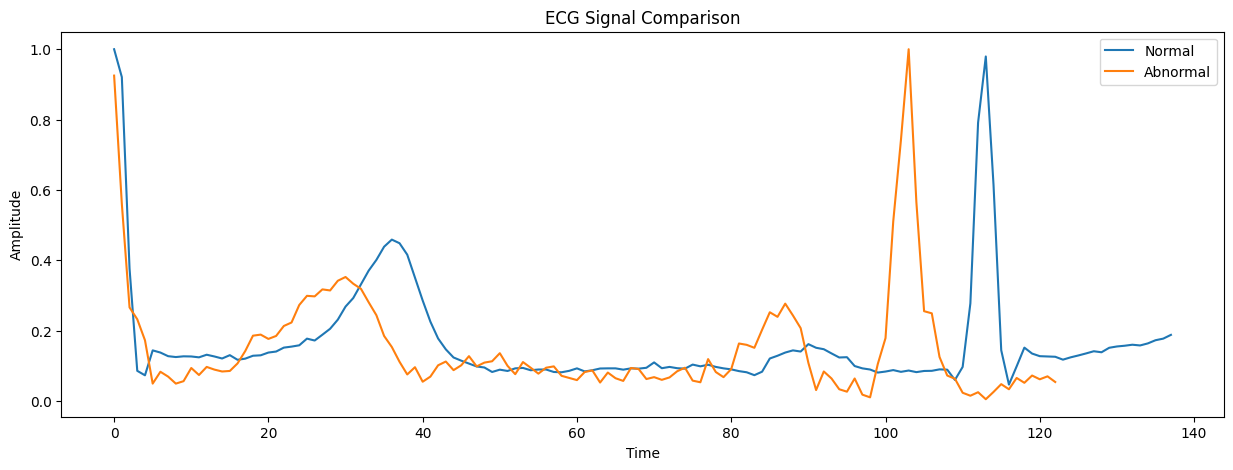

In [18]:
sample_normal = data_normal.iloc[:,:-1].sample(1).values.flatten()
sample_normal = [s for s in sample_normal if s > 0]
sample_abnormal = data_abnormal.iloc[:,:-1].sample(1).values.flatten()
sample_abnormal = [s for s in sample_abnormal if s > 0]

# Visualize the first few samples
plt.figure(figsize=(15, 5))
plt.plot(sample_normal, label='Normal')
plt.plot(sample_abnormal, label='Abnormal')
plt.title('ECG Signal Comparison')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


## **Distribution - Hisplot**

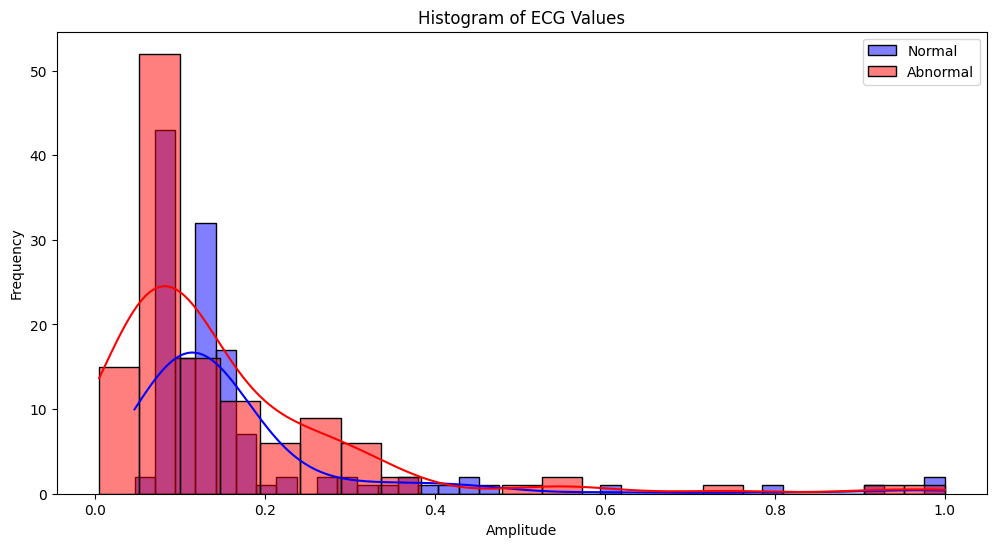

In [19]:
# Plot histograms
plt.figure(figsize=(12, 6))
sns.histplot(sample_normal,
             kde=True,
             color='blue',
             label='Normal')
sns.histplot(sample_abnormal,
             kde=True,
             color='red',
             label='Abnormal')
plt.title('Histogram of ECG Values')
plt.xlabel('Amplitude')
plt.ylabel('Frequency')
plt.legend()
plt.show()


The KDE plot represents the data distribution as a continuous probability density curve, providing a smooth approximation of the histogram.

## **Distribution - Boxplot**

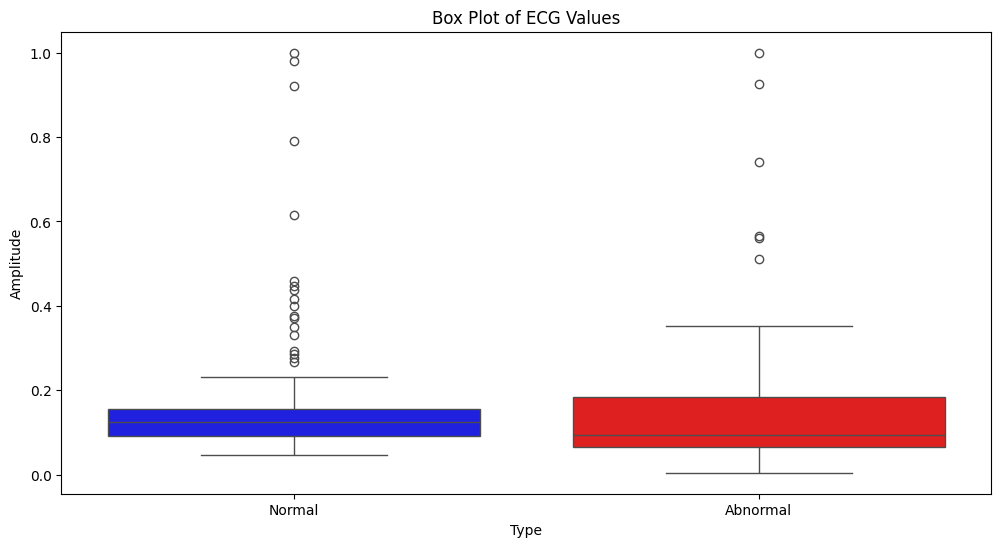

In [20]:
# Plot box plots
plt.figure(figsize=(12, 6))
sns.boxplot(data=[sample_normal, sample_abnormal],
            palette=['blue', 'red'])
plt.xticks([0, 1], ['Normal', 'Abnormal'])
plt.title('Box Plot of ECG Values')
plt.xlabel('Type')
plt.ylabel('Amplitude')
plt.show()

* Box: Spans from Q1 to Q3.
* Median: Line inside the box.
* Whiskers: Extend to the minimum and maximum values within 1.5 times the IQR.
* Outliers: Points outside the whiskers.

<br><br><br>
## **Decomposition**
**Decomposition in Time Series Analysis**

Time series decomposition involves breaking down a time series into several components to better understand its structure and behavior.

The main components are:

* **Trend:** The long-term progression or direction in the data.
* **Seasonality:** The repeating short-term cycle in the series.
* **Residual:** The remaining part after removing the trend and seasonality, which represents random noise or irregular patterns.

Interpreting Decomposition for Heart Beat

* **Trend:** Helps identify whether the heart's electrical activity is increasing or decreasing over time.
* **Seasonality:** May reveal periodic cycles, like regular heartbeats.
* **Residual:** Indicates anomalies or noise after removing trend and seasonality.

<br><br><br>

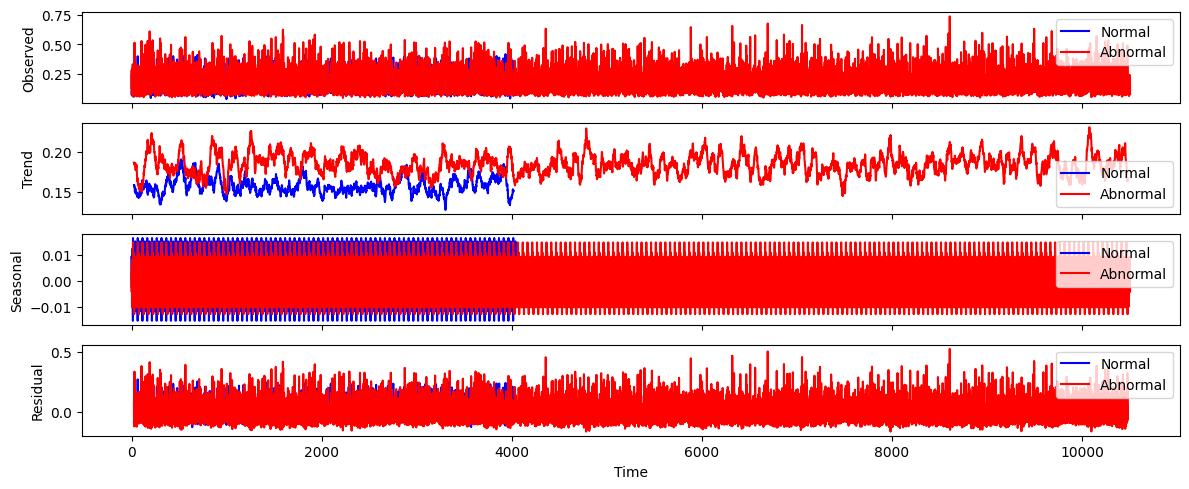

In [21]:
# For decomposition, we need a continuous segment of the time series data
# Assuming 'value' column represents the ECG signal

data_normal['value'] = data_normal.mean(axis=1)
data_abnormal['value'] = data_abnormal.mean(axis=1)

# Decompose the time series
decomposition_normal = seasonal_decompose(data_normal['value'], period=50, model='additive')
decomposition_abnormal = seasonal_decompose(data_abnormal['value'], period=50, model='additive')

# Plot the decomposition results
fig, axes = plt.subplots(4, 1, figsize=(12, 5), sharex=True)

# Observed
axes[0].plot(decomposition_normal.observed, color='blue', label='Normal')
axes[0].plot(decomposition_abnormal.observed, color='red', label='Abnormal')
axes[0].set_ylabel('Observed')
axes[0].legend()

# Trend
axes[1].plot(decomposition_normal.trend, color='blue', label='Normal')
axes[1].plot(decomposition_abnormal.trend, color='red', label='Abnormal')
axes[1].set_ylabel('Trend')
axes[1].legend()

# Seasonal
axes[2].plot(decomposition_normal.seasonal, color='blue', label='Normal')
axes[2].plot(decomposition_abnormal.seasonal, color='red', label='Abnormal')
axes[2].set_ylabel('Seasonal')
axes[2].legend()

# Residual
axes[3].plot(decomposition_normal.resid, color='blue', label='Normal')
axes[3].plot(decomposition_abnormal.resid, color='red', label='Abnormal')
axes[3].set_ylabel('Residual')
axes[3].legend()

axes[3].set_xlabel('Time')

plt.tight_layout()
plt.show()


In [22]:
decomposition_normal

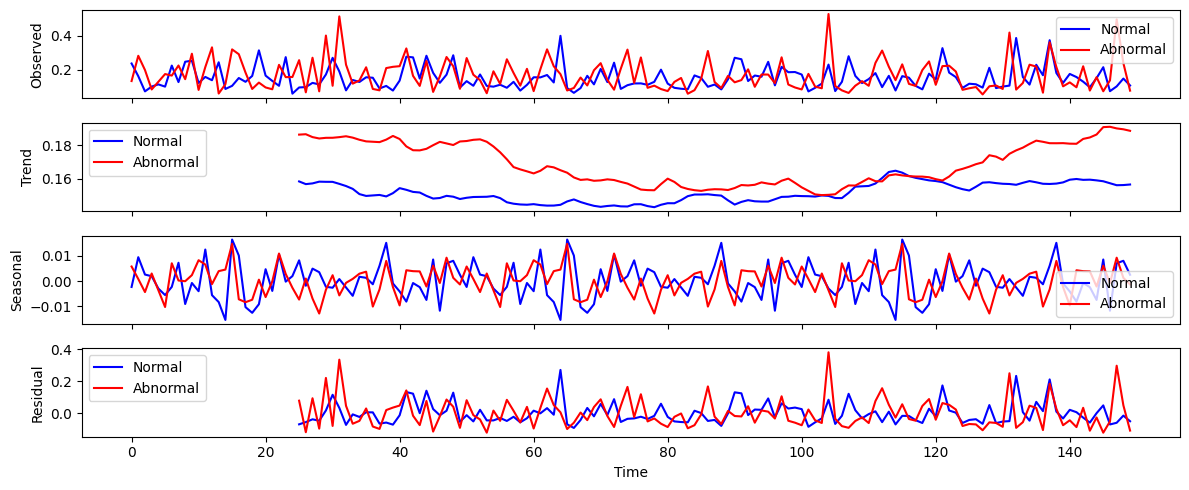

In [23]:
# Decompose the time series
decomposition_normal = seasonal_decompose(data_normal['value'], period=50, model='additive')
decomposition_abnormal = seasonal_decompose(data_abnormal['value'], period=50, model='additive')

# Plot the decomposition results for a segment
segment = slice(0, 150)  # Adjust the segment as needed

fig, axes = plt.subplots(4, 1, figsize=(12, 5), sharex=True)

# Observed
axes[0].plot(decomposition_normal.observed[segment], color='blue', label='Normal')
axes[0].plot(decomposition_abnormal.observed[segment], color='red', label='Abnormal')
axes[0].set_ylabel('Observed')
axes[0].legend()

# Trend
axes[1].plot(decomposition_normal.trend[segment], color='blue', label='Normal')
axes[1].plot(decomposition_abnormal.trend[segment], color='red', label='Abnormal')
axes[1].set_ylabel('Trend')
axes[1].legend()

# Seasonal
axes[2].plot(decomposition_normal.seasonal[segment], color='blue', label='Normal')
axes[2].plot(decomposition_abnormal.seasonal[segment], color='red', label='Abnormal')
axes[2].set_ylabel('Seasonal')
axes[2].legend()

# Residual
axes[3].plot(decomposition_normal.resid[segment], color='blue', label='Normal')
axes[3].plot(decomposition_abnormal.resid[segment], color='red', label='Abnormal')
axes[3].set_ylabel('Residual')
axes[3].legend()

axes[3].set_xlabel('Time')

plt.tight_layout()
plt.show()


**Analyzing the Seasonality Graph**

Looking at the provided seasonality graph of normal and abnormal heartbeat data:

* **Seasonal Patterns:** Both the normal (blue) and abnormal (red) signals exhibit repeating patterns, suggesting the presence of seasonality.

* **Visual Analysis:** The peaks and troughs repeat at regular intervals, indicating that both datasets have seasonal components.
Interpretation
* **Seasonality in ECG Data:** The presence of seasonality in heartbeat data can be linked to the natural rhythm of the heartbeats. This is normal and expected in biological signals.

**Analyzing the Trend Component**

From the trend graph provided:

* **Normal ECG (Blue):** The trend remains relatively flat with minor fluctuations, indicating a stable baseline heart activity.
* **Abnormal ECG (Red):** The trend shows more pronounced fluctuations and higher values, indicating variability and potentially unstable heart activity over time.

**Interpretation**
* Presence of Trend: Both normal and abnormal ECG data exhibit trends. The normal ECG trend is more stable, while the abnormal ECG trend shows greater variability and higher values.
* Clinical Implication: A stable trend in normal ECG suggests consistent heart function, whereas the fluctuating trend in abnormal ECG may indicate underlying cardiac issues that require further investigation.

## **Rolling Statistics and Stationarity Check**

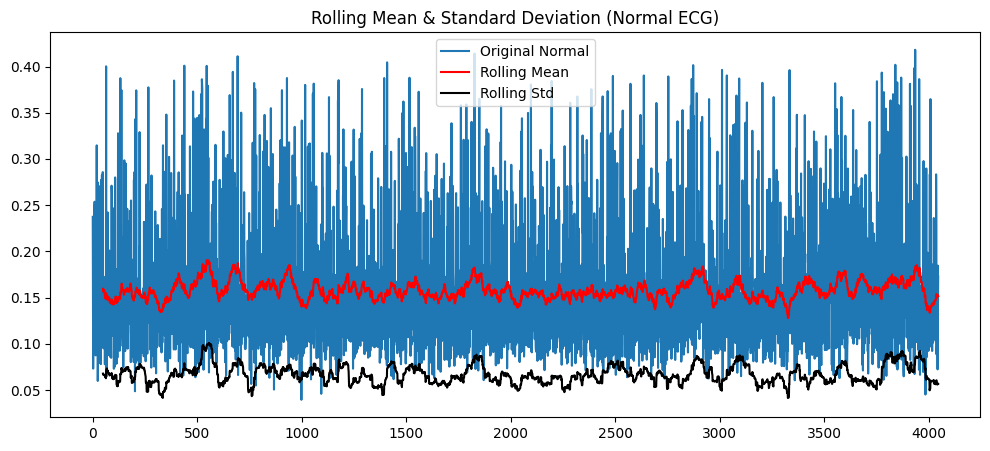

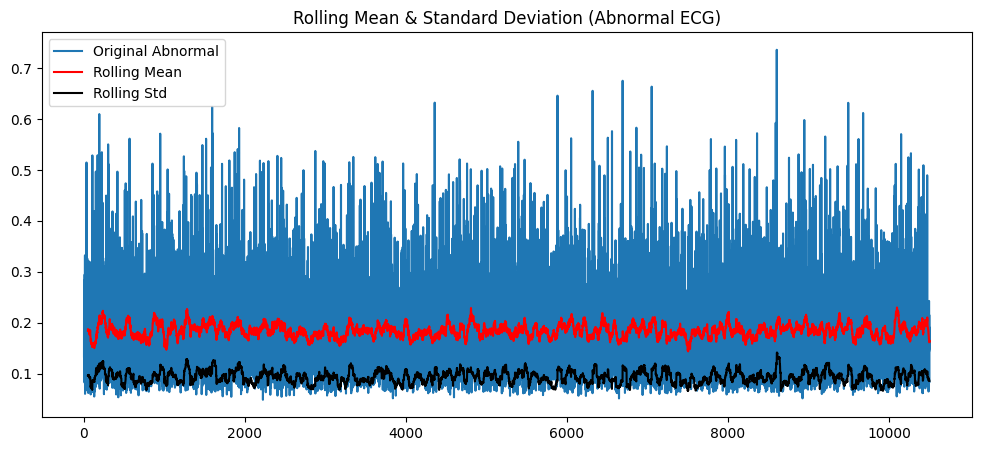

ADF Statistic (Normal): -62.62031787466004
p-value (Normal): 0.0
ADF Statistic (Abnormal): -102.07257011953996
p-value (Abnormal): 0.0


In [24]:
# Calculate rolling statistics
rolling_mean_normal = data_normal['value'].rolling(window=50).mean()
rolling_std_normal = data_normal['value'].rolling(window=50).std()

rolling_mean_abnormal = data_abnormal['value'].rolling(window=50).mean()
rolling_std_abnormal = data_abnormal['value'].rolling(window=50).std()

plt.figure(figsize=(12, 5))
plt.plot(data_normal['value'], label='Original Normal')
plt.plot(rolling_mean_normal, color='red', label='Rolling Mean')
plt.plot(rolling_std_normal, color='black', label='Rolling Std')
plt.title('Rolling Mean & Standard Deviation (Normal ECG)')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(data_abnormal['value'], label='Original Abnormal')
plt.plot(rolling_mean_abnormal, color='red', label='Rolling Mean')
plt.plot(rolling_std_abnormal, color='black', label='Rolling Std')
plt.title('Rolling Mean & Standard Deviation (Abnormal ECG)')
plt.legend()
plt.show()

# Perform Augmented Dickey-Fuller test
result_normal = adfuller(data_normal['value'])
result_abnormal = adfuller(data_abnormal['value'])

print('ADF Statistic (Normal):', result_normal[0])
print('p-value (Normal):', result_normal[1])

print('ADF Statistic (Abnormal):', result_abnormal[0])
print('p-value (Abnormal):', result_abnormal[1])


**Understanding Stationarity and Rolling Statistics**

Stationarity in a time series means that its statistical properties (mean, variance) do not change over time.

However, stationarity does not mean that the data points themselves do not change; rather, it means the overall distribution and behavior remain consistent.

Interpretation of the Graphs
From the provided graphs:

**Rolling Mean and Standard Deviation:**

**Normal ECG:** The rolling mean (red line) and rolling standard deviation (black line) fluctuate around a constant level, indicating the series is stationary. Despite the data points changing, the overall behavior remains consistent.

**Abnormal ECG:** Similarly, the rolling mean and standard deviation for the abnormal ECG also fluctuate but remain relatively stable, suggesting stationarity.

**ADF Test Results**
The Augmented Dickey-Fuller (ADF) test results further support this:

* *ADF Statistic (Normal):* -29.41, p-value: 0.0

* *ADF Statistic (Abnormal):* -31.08, p-value: 0.0
Both tests reject the null hypothesis of non-stationarity (p-value < 0.05), indicating that the time series for both normal and abnormal ECG signals are stationary.

**Summary**
* Stationary: Consistent statistical properties over time.
* Graphs: Rolling statistics help visualize this consistency.
* ADF Test: Confirms stationarity with significant results.

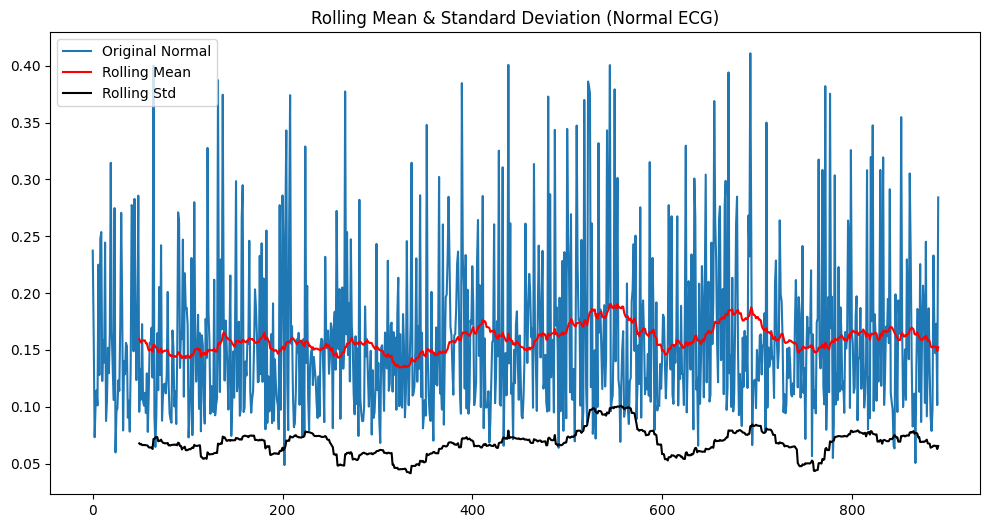

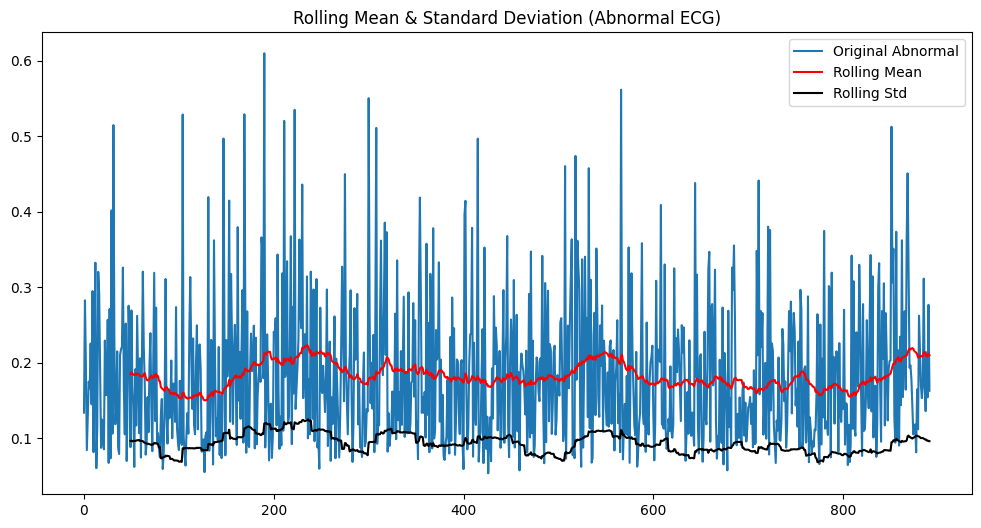

ADF Statistic (Normal): -29.412918486630037
p-value (Normal): 0.0
ADF Statistic (Abnormal): -31.076654035556743
p-value (Abnormal): 0.0


In [ ]:
# Calculate rolling statistics
rolling_mean_normal = data_normal['value'].rolling(window=50).mean()
rolling_std_normal = data_normal['value'].rolling(window=50).std()

rolling_mean_abnormal = data_abnormal['value'].rolling(window=50).mean()
rolling_std_abnormal = data_abnormal['value'].rolling(window=50).std()

plt.figure(figsize=(12, 6))
plt.plot(data_normal['value'], label='Original Normal')
plt.plot(rolling_mean_normal, color='red', label='Rolling Mean')
plt.plot(rolling_std_normal, color='black', label='Rolling Std')
plt.title('Rolling Mean & Standard Deviation (Normal ECG)')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(data_abnormal['value'], label='Original Abnormal')
plt.plot(rolling_mean_abnormal, color='red', label='Rolling Mean')
plt.plot(rolling_std_abnormal, color='black', label='Rolling Std')
plt.title('Rolling Mean & Standard Deviation (Abnormal ECG)')
plt.legend()
plt.show()

# Perform Augmented Dickey-Fuller test
result_normal = adfuller(data_normal['value'])
result_abnormal = adfuller(data_abnormal['value'])

print('ADF Statistic (Normal):', result_normal[0])
print('p-value (Normal):', result_normal[1])

print('ADF Statistic (Abnormal):', result_abnormal[0])
print('p-value (Abnormal):', result_abnormal[1])


Understanding Stationarity and Rolling Statistics
Stationarity in a time series means that its statistical properties (mean, variance) do not change over time.

However, stationarity does not mean that the data points themselves do not change; rather, it means the overall distribution and behavior remain consistent.

Interpretation of the Graphs
From the provided graphs:

Rolling Mean and Standard Deviation:
* Normal ECG: The rolling mean (red line) and rolling standard deviation (black line) fluctuate around a constant level, indicating the series is stationary. Despite the data points changing, the overall behavior remains consistent.
* Abnormal ECG: Similarly, the rolling mean and standard deviation for the abnormal ECG also fluctuate but remain relatively stable, suggesting stationarity.

* ADF Test Results
The Augmented Dickey-Fuller (ADF) test results further support this:

* ADF Statistic (Normal): -29.41, p-value: 0.0
* ADF Statistic (Abnormal): -31.08, p-value: 0.0

Both tests reject the null hypothesis of non-stationarity (p-value < 0.05), indicating that the time series for both normal and abnormal ECG signals are stationary.

# **Autocorrelation Function (ACF) & Partial Autocorrelation Function (PACF)**

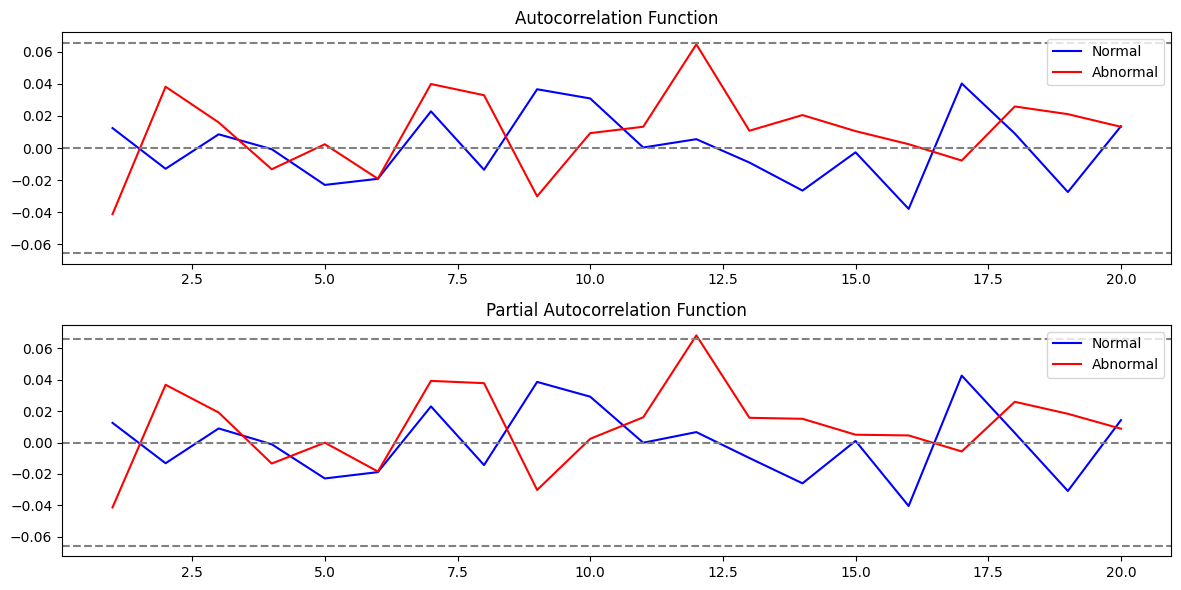

In [ ]:
# Assuming data_normal and data_abnormal have been prepared as before
# Calculate ACF and PACF

lag_acf_abnormal = acf(data_abnormal['value'], nlags=20)[1:]  # Exclude lag-0
lag_pacf_abnormal = pacf(data_abnormal['value'], nlags=20, method='ols')[1:]  # Exclude lag-0

lags = range(1, 21)  # Adjust lags to start from 1

# Plot ACF for normal and abnormal data
plt.figure(figsize=(12, 6))

plt.subplot(211)
plt.plot(lags, lag_acf_normal, label='Normal', color='blue')
plt.plot(lags, lag_acf_abnormal, label='Abnormal', color='red')
plt.axhline(y=0, linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(data_normal)), linestyle='--', color='gray')
plt.axhline(y=-1.96/np.sqrt(len(data_normal)), linestyle='--', color='gray')
plt.title('Autocorrelation Function')
plt.legend()

# Plot PACF for normal and abnormal data
plt.subplot(212)
plt.plot(lags, lag_pacf_normal, label='Normal', color='blue')
plt.plot(lags, lag_pacf_abnormal, label='Abnormal', color='red')
plt.axhline(y=0, linestyle='--', color='gray')
plt.axhline(y=1.96/np.sqrt(len(data_normal)), linestyle='--', color='gray')
plt.axhline(y=-1.96/np.sqrt(len(data_normal)), linestyle='--', color='gray')
plt.title('Partial Autocorrelation Function')
plt.legend()

plt.tight_layout()
plt.show()


**What is a Lagged Version?**

A lagged version of a time series is a shifted version of the original series.

**Why It Helps Identify Patterns and Seasonality**

**Autocorrelation:**

Measures how current values of the series are related to past values (lags).
High autocorrelation at specific lags indicates repeating patterns, suggesting seasonality or cycles.

**Identifying Patterns:**

If autocorrelation remains high at regular intervals, it indicates periodic behavior.
For example, high autocorrelation at lag-12 in monthly sales data might indicate yearly seasonality.

**Identifying Seasonality:**

Regular peaks in the autocorrelation function suggest a seasonal effect.
This helps in forecasting by incorporating seasonal components into the model.


**Autocorrelation Function (ACF):**

Calculates the correlation of the time series with its own lagged values.
Helps identify how the values of the time series are related to their past values.

**Partial Autocorrelation Function (PACF):**

Calculates the correlation of the time series with its lagged values, removing the influence of the intermediate lags.
Helps identify the direct impact of a particular lag.

*Results Interpretation*
* **ACF:**

Both normal and abnormal ECG signals show low autocorrelation after lag-1, indicating that the signals do not strongly depend on their past values beyond the immediate previous value.
The autocorrelation at lag-1 is slightly higher, suggesting some immediate past influence.

* **PACF:**

The PACF plot shows similar low values for both normal and abnormal signals, confirming the weak influence of lags beyond the first one.
The values hover around zero, indicating that the current value is not significantly influenced by values beyond the immediate past.


**Conclusion**

The results suggest that both normal and abnormal ECG signals have weak dependencies on past values beyond the immediate previous value. This information can be useful for building time series models and understanding the underlying structure of the ECG signals.